# 08. Experiment Readouts for Business Teams

An experiment is not finished when the model runs or the p-value appears. It is finished when a team can make a better decision than it could have made before the experiment.

That sounds obvious, but many experiment readouts fail at exactly this point. They show a dense table of metrics, a few green or red arrows, and a sentence like "primary metric is statistically significant." A business team needs something sharper:

- What decision was the experiment designed to inform?
- Can we trust the data?
- What moved, by how much, and with what uncertainty?
- Did guardrails pass?
- Is the effect large enough to matter?
- What should we do now?

The central idea of this notebook is:

> A good readout turns causal evidence into a decision, without hiding uncertainty or overselling exploratory results.

This notebook builds a complete experiment readout for a simulated product experiment. The same structure applies to industry causal inference projects, ML product launches, ranking tests, LLM feature rollouts, pricing tests, operations interventions, and customer-success programs.

## Learning Goals

By the end of this notebook, you should be able to:

- Structure an experiment readout around a decision rather than a metric dump.
- Separate trust checks, primary metrics, guardrails, and diagnostics.
- Create metric-level tables with estimates, confidence intervals, practical thresholds, and decision labels.
- Explain why p-values alone are insufficient for business decisions.
- Build sample-ratio, telemetry, invariant, and guardrail checks.
- Communicate uncertainty using confidence intervals and decision thresholds.
- Treat segment and diagnostic analyses as hypothesis-generating unless pre-specified.
- Produce an executive summary that is accurate, concise, and actionable.
- Build reusable readout artifacts that can be updated as experiments mature.

## Mathematical Setup: Turning Evidence into a Decision

A readout should still make the statistical objects explicit. For metric $m$, the experiment estimate is usually:

$$
\widehat{\tau}_m = \bar{Y}_{m,Z=1} - \bar{Y}_{m,Z=0}
$$

A standard confidence interval reports uncertainty around that estimate:

$$
\widehat{\tau}_m \pm z_{1-\alpha/2}SE(\widehat{\tau}_m)
$$

For a launch decision, the primary metric is only one constraint. Let $G_j$ be guardrail metric $j$ and let $b_j$ be the largest acceptable harm. A simple decision rule is:

$$
\text{Launch if } \widehat{\tau}_{primary} > \delta \text{ and } \widehat{\tau}_{G_j} > -b_j \text{ for every guardrail } j
$$

The exact business rule can vary, but the structure matters. The recommendation should combine effect size, uncertainty, assignment integrity, guardrails, and known risks. A p-value alone is not a decision rule.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from graphviz import Digraph
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260428)

COLORS = {
    "trust": "#d7ecff",
    "primary": "#dff0d8",
    "guardrail": "#ffe0c2",
    "diagnostic": "#eadcf8",
    "warning": "#fff1c7",
    "decision": "#ffd6db",
    "neutral": "#f7f7f7",
}

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.55", ranksep="0.70")
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        color="#2b2b2b",
        fontname="Helvetica",
        fontsize="11",
        margin="0.12,0.08",
    )
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([node for edge in edges for node in edge[:2]]))
    for node in nodes:
        dot.node(node, fillcolor=node_colors.get(node, COLORS["neutral"]))
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            dot.edge(src, dst)
        elif len(edge) == 3:
            src, dst, label = edge
            dot.edge(src, dst, label=label)
    return dot


def summarize_difference(df, metric, variant="assigned", metric_type="continuous"):
    """
    Summarize an experiment metric with an estimate and large-sample confidence interval.
    
    Idea:
        This turns raw metric columns into readout-ready effect estimates for business interpretation.
    
    Args:
        df: DataFrame containing the treatment, outcome, cluster, or covariate columns needed by the helper.
        metric: Experiment metric column being summarized.
        variant: Column identifying control and treatment arms in the experiment readout.
        metric_type: Whether the metric is continuous, binary, or otherwise summarized for the readout.
    
    Returns:
        dict: Metric name, estimate, standard error, interval, and sample summaries.
    """
    treat = df.loc[df[variant] == 1, metric]
    control = df.loc[df[variant] == 0, metric]
    estimate = treat.mean() - control.mean()
    se = np.sqrt(treat.var(ddof=1) / len(treat) + control.var(ddof=1) / len(control))
    if metric_type == "binary":
        p1 = treat.mean()
        p0 = control.mean()
        se = np.sqrt(p1 * (1 - p1) / len(treat) + p0 * (1 - p0) / len(control))
    z = estimate / se if se > 0 else np.nan
    p_value = 2 * (1 - stats.norm.cdf(abs(z))) if se > 0 else np.nan
    return {
        "control_mean": control.mean(),
        "treatment_mean": treat.mean(),
        "estimate": estimate,
        "se": se,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
        "p_value": p_value,
        "n_control": len(control),
        "n_treatment": len(treat),
    }


def practical_status(row):
    """
    Classify an estimated metric effect against practical launch thresholds.
    
    Idea:
        The label distinguishes statistical movement from effects large enough to matter for the decision.
    
    Args:
        row: Metric summary row being converted into a practical launch label.
    
    Returns:
        str: Decision label such as positive, neutral, or guardrail concern.
    """
    role = row["role"]
    direction = row["direction"]
    threshold = row["practical_threshold"]
    if role == "primary":
        if row["ci_low"] >= threshold:
            return "decision-grade positive"
        if row["ci_high"] < threshold and row["ci_high"] > 0:
            return "positive but below threshold"
        if row["ci_high"] <= 0:
            return "no evidence of lift"
        return "promising but uncertain"
    if role == "guardrail":
        if direction == "lower_is_better":
            return "pass" if row["ci_high"] <= threshold else "watch / possible harm"
        if direction == "higher_is_better":
            return "pass" if row["ci_low"] >= threshold else "watch / possible harm"
    return "diagnostic"


def plot_metric_effects(table, title, xlabel="Treatment - control", figsize=(9.5, 5.0)):
    """Plot experiment metric effects with decision thresholds and guardrail labels.

    Args:
        table: Summary table containing estimates, intervals, or diagnostics.
        title: Title shown on the resulting figure.
        xlabel: X-axis label for the resulting figure.
        figsize: Matplotlib figure size.

    Returns:
        tuple: Matplotlib figure and axes for the metric-effect readout.
    """
    ordered = table.copy().sort_values(["role", "estimate"])
    palette = {
        "primary": "#1f7a4d",
        "guardrail": "#b45309",
        "secondary": "#2f6f9f",
        "diagnostic": "#6b7280",
    }
    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(ordered))
    colors = [palette.get(role, "#6b7280") for role in ordered["role"]]
    for idx, (_, row) in enumerate(ordered.iterrows()):
        color = palette.get(row["role"], "#6b7280")
        ax.errorbar(
            row["estimate"],
            idx,
            xerr=[[row["estimate"] - row["ci_low"]], [row["ci_high"] - row["estimate"]]],
            fmt="o",
            color=color,
            ecolor=color,
            markeredgecolor="#222222",
            markeredgewidth=0.7,
            elinewidth=2,
            capsize=4,
            markersize=7,
        )
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(ordered["metric_label"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 1. A Readout Is a Decision Artifact

The output of an experiment is not a table. The output is a recommendation supported by evidence.

A professional readout has four layers.

| Layer | Question | Examples |
|---|---|---|
| Trust checks | Can we trust this experiment? | Sample ratio, telemetry, invariant metrics, logging, eligibility |
| Primary decision metric | Did the treatment accomplish the goal? | Revenue, retention, productivity, conversion, cost per case |
| Guardrails | Did it harm something important? | Latency, errors, churn, support tickets, fairness, refunds |
| Diagnostics | Why did it move, and where should we investigate? | Funnels, segments, trigger rates, mechanism metrics |

Online controlled experiments are widely used to support data-driven product decisions, but trustworthy practice requires attention to operational and methodological pitfalls (Kohavi et al., 2009; Bojinov & Gupta, 2022; Kohavi et al., 2020). Wasserstein and Lazar (2016) also warn against reducing scientific, policy, or business decisions to whether a p-value crosses a threshold. A readout should include effect sizes, uncertainty, practical importance, and decision context.

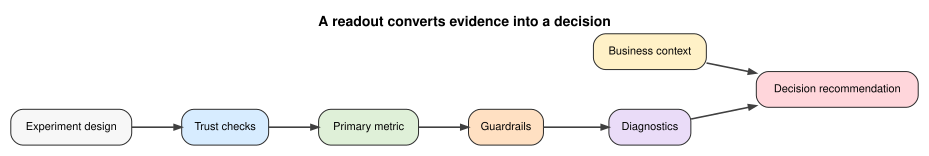

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
readout_edges = [
    ("Experiment design", "Trust checks"),
    ("Trust checks", "Primary metric"),
    ("Primary metric", "Guardrails"),
    ("Guardrails", "Diagnostics"),
    ("Diagnostics", "Decision recommendation"),
    ("Business context", "Decision recommendation"),
]
readout_colors = {
    "Experiment design": COLORS["neutral"],
    "Trust checks": COLORS["trust"],
    "Primary metric": COLORS["primary"],
    "Guardrails": COLORS["guardrail"],
    "Diagnostics": COLORS["diagnostic"],
    "Business context": COLORS["warning"],
    "Decision recommendation": COLORS["decision"],
}

smart_display(make_dag(readout_edges, "A readout converts evidence into a decision", readout_colors))

The flow is deliberate. Do not start with the most exciting metric. Start with whether the experiment is trustworthy. Then show the primary metric, then guardrails, then diagnostics. This order prevents teams from chasing a favorable segment result before confirming that the experiment can support a decision.

## 2. The Simulated Experiment

We will use a product experiment throughout the notebook.

A SaaS company tests an AI onboarding assistant for new enterprise accounts. Eligible accounts are randomly assigned to treatment or control. The treatment gives the account team an AI-guided onboarding workflow. The business wants to decide whether to roll it out to all eligible enterprise accounts.

The pre-specified readout plan is:

| Item | Choice |
|---|---|
| Decision | Roll out the assistant to all eligible enterprise accounts? |
| Unit of randomization | Account |
| Primary metric | 14-day account value |
| Practical threshold | At least +0.25 value units |
| Secondary metrics | Activation, 14-day retention, assistant usage |
| Guardrails | Latency, support tickets, error rate |
| Trust checks | Sample ratio, telemetry completeness, pre-period value balance |
| Main caveat | Short-term experiment may not fully capture long-term support load |

A readout should say these choices before showing results. Otherwise the analysis can drift into metric shopping.

**Dataset and experiment setup.** The simulated readout represents a product experiment after data collection is complete. Each row is a user or account with assignment, primary outcome, guardrail outcomes, invariant checks, pre-period behavior, and segment labels. The treatment effect is intentionally not the only thing that matters. The readout has to decide whether the experiment was implemented correctly, whether the primary lift is practically meaningful, whether guardrails were harmed, and whether subgroup patterns are stable enough to act on. This mirrors the structure of an industry launch review.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_readout_experiment(n=24000, seed=20260428):
    """Generate a full experiment-readout dataset with primary, guardrail, invariant, and segment variables.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    local_rng = np.random.default_rng(seed)
    account_id = np.arange(n)
    assigned = np.zeros(n, dtype=int)
    assigned[local_rng.choice(n, size=n // 2, replace=False)] = 1

    plan = local_rng.choice(["startup", "growth", "enterprise"], size=n, p=[0.34, 0.42, 0.24])
    region = local_rng.choice(["North America", "Europe", "APAC", "LATAM"], size=n, p=[0.45, 0.30, 0.18, 0.07])
    device = local_rng.choice(["desktop", "mobile"], size=n, p=[0.72, 0.28])
    has_ai_history = local_rng.binomial(1, 0.28 + 0.10 * (plan == "enterprise"), size=n)

    plan_value = pd.Series(plan).map({"startup": -2.0, "growth": 0.0, "enterprise": 3.8}).to_numpy()
    region_value = pd.Series(region).map({"North America": 0.8, "Europe": 0.3, "APAC": -0.2, "LATAM": -0.5}).to_numpy()
    pre_value = 52 + plan_value + region_value + 2.2 * has_ai_history + local_rng.normal(0, 8.0, n)

    # The treatment effect is positive on average and a bit larger for enterprise accounts.
    treatment_effect = 0.50 + 0.18 * (plan == "enterprise") + 0.10 * has_ai_history - 0.08 * (device == "mobile")
    value_14d = 20 + 0.56 * pre_value + plan_value + region_value + treatment_effect * assigned + local_rng.normal(0, 7.5, n)

    activation_logit = -0.55 + 0.38 * assigned + 0.025 * (pre_value - pre_value.mean()) + 0.28 * has_ai_history
    activation = local_rng.binomial(1, 1 / (1 + np.exp(-activation_logit)))

    retention_logit = -0.20 + 0.08 * assigned + 0.020 * (pre_value - pre_value.mean()) + 0.18 * activation
    retained_14d = local_rng.binomial(1, 1 / (1 + np.exp(-retention_logit)))

    usage_logit = -1.15 + 1.20 * assigned + 0.45 * has_ai_history + 0.015 * (pre_value - pre_value.mean())
    used_assistant = local_rng.binomial(1, 1 / (1 + np.exp(-usage_logit)))

    latency_ms = 240 + 12.0 * assigned + 12.0 * (device == "mobile") + local_rng.normal(0, 35.0, n)
    support_rate = np.exp(-2.55 - 0.06 * assigned + 0.12 * (plan == "enterprise") + 0.08 * (device == "mobile"))
    support_tickets = local_rng.poisson(support_rate)
    error_rate = local_rng.binomial(1, 0.009 + 0.0012 * assigned + 0.003 * (device == "mobile"), n)

    # Observability is a trust issue; a small amount of telemetry is lost, especially on mobile.
    observed_prob = 0.994 - 0.003 * assigned - 0.010 * (device == "mobile")
    telemetry_observed = local_rng.binomial(1, np.clip(observed_prob, 0.95, 0.999), n)

    return pd.DataFrame({
        "account_id": account_id,
        "assigned": assigned,
        "plan": plan,
        "region": region,
        "device": device,
        "has_ai_history": has_ai_history,
        "pre_value": pre_value,
        "value_14d": value_14d,
        "activation": activation,
        "retained_14d": retained_14d,
        "used_assistant": used_assistant,
        "latency_ms": latency_ms,
        "support_tickets": support_tickets,
        "error_rate": error_rate,
        "telemetry_observed": telemetry_observed,
    })


df = simulate_readout_experiment()
observed_df = df.query("telemetry_observed == 1").copy()

print(f"Randomized accounts: {len(df):,}")
print(f"Accounts with primary telemetry: {len(observed_df):,}")
print(f"Overall telemetry completeness: {df['telemetry_observed'].mean():.3%}")
df.head()

Randomized accounts: 24,000
Accounts with primary telemetry: 23,744
Overall telemetry completeness: 98.933%


,account_id,assigned,plan,region,device,has_ai_history,pre_value,value_14d,activation,retained_14d,used_assistant,latency_ms,support_tickets,error_rate,telemetry_observed
0,0,1,startup,North America,desktop,0,45.668426,38.290421,0,0,0,238.216975,0,0,1
1,1,0,enterprise,Europe,desktop,1,53.373163,65.666021,1,0,1,282.572286,0,0,1
2,2,0,enterprise,Europe,desktop,0,54.879169,55.254085,1,0,0,276.116250,0,0,1
3,3,0,growth,North America,desktop,0,52.157066,40.398952,1,1,0,284.997448,0,0,1
4,4,1,startup,North America,desktop,1,44.293426,49.546447,0,1,1,210.839064,0,0,1


This is a simulated dataset, but the data structure is realistic: account-level randomization, pre-treatment covariates, primary outcome, secondary metrics, guardrails, and telemetry completeness.

The important discipline is that analysis should use the pre-specified metric roles. We can explore other patterns, but we should not let exploration rewrite the launch rule after seeing the data.

## 3. Trust Check 1: Sample Ratio and Assignment Integrity

The first readout question is not "Did we win?" It is "Did randomization and logging behave?"

A **sample ratio mismatch** check compares observed assignment counts with planned assignment probabilities. A large mismatch can indicate an assignment, eligibility, logging, or filtering problem. If assignment integrity is broken, causal interpretation is at risk.

In [5]:
# Assemble the Trust Check 1: Sample Ratio and Assignment Integrity summary table used for interpretation.
planned_share = 0.50
assignment_counts = df["assigned"].value_counts().sort_index()
observed_counts = observed_df["assigned"].value_counts().sort_index()
expected_randomized = np.array([len(df) * (1 - planned_share), len(df) * planned_share])
expected_observed = np.array([len(observed_df) * (1 - planned_share), len(observed_df) * planned_share])

srm_randomized = stats.chisquare(assignment_counts.to_numpy(), f_exp=expected_randomized)
srm_observed = stats.chisquare(observed_counts.to_numpy(), f_exp=expected_observed)

srm_table = pd.DataFrame({
    "population": ["Randomized accounts", "Accounts with telemetry"],
    "control_count": [assignment_counts.loc[0], observed_counts.loc[0]],
    "treatment_count": [assignment_counts.loc[1], observed_counts.loc[1]],
    "treatment_share": [assignment_counts.loc[1] / assignment_counts.sum(), observed_counts.loc[1] / observed_counts.sum()],
    "srm_p_value": [srm_randomized.pvalue, srm_observed.pvalue],
})
srm_table.round(4)

,population,control_count,treatment_count,treatment_share,srm_p_value
0,Randomized accounts,12000,12000,0.5000,1.0000
1,Accounts with telemetry,11888,11856,0.4993,0.8355


In Trust Check 1: Sample Ratio and Assignment Integrity, the table is a design check. Outcome interpretation comes after the assignment table looks consistent with the design.

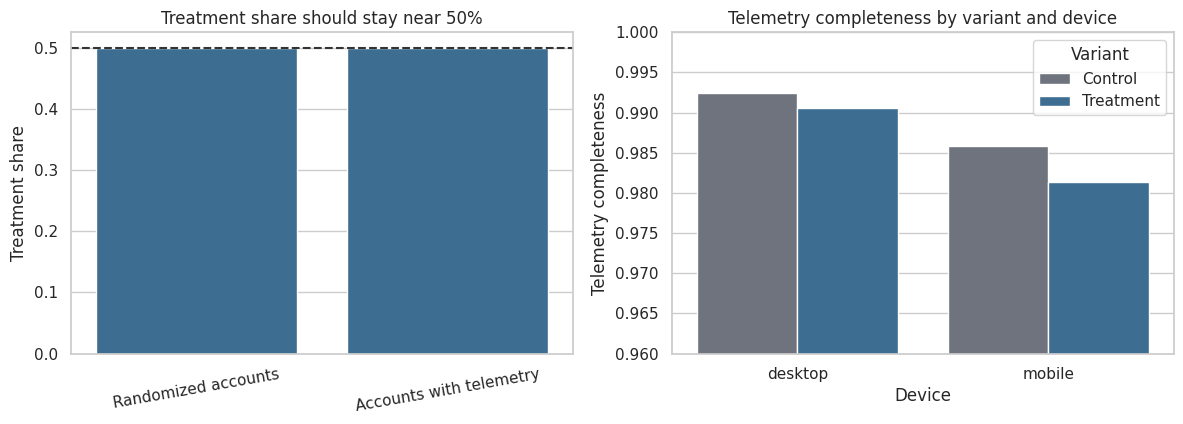

In [6]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
telemetry_table = (
    df.groupby(["assigned", "device"], as_index=False)
    .agg(
        accounts=("account_id", "size"),
        telemetry_rate=("telemetry_observed", "mean"),
    )
)
telemetry_table["variant"] = telemetry_table["assigned"].map({0: "Control", 1: "Treatment"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
sns.barplot(data=srm_table, x="population", y="treatment_share", color="#2f6f9f", ax=axes[0])
axes[0].axhline(0.50, color="#333333", linestyle="--", linewidth=1.5)
axes[0].set_title("Treatment share should stay near 50%")
axes[0].set_xlabel("")
axes[0].set_ylabel("Treatment share")
axes[0].tick_params(axis="x", rotation=10)

sns.barplot(data=telemetry_table, x="device", y="telemetry_rate", hue="variant", palette=["#6b7280", "#2f6f9f"], ax=axes[1])
axes[1].set_title("Telemetry completeness by variant and device")
axes[1].set_xlabel("Device")
axes[1].set_ylabel("Telemetry completeness")
axes[1].set_ylim(0.96, 1.0)
axes[1].legend(title="Variant")
plt.tight_layout()
plt.show()

The randomized assignment counts are exactly balanced by construction. The observed telemetry population is still close to balanced, but telemetry completeness is slightly lower for mobile and treatment. That pattern should be documented before interpreting the outcome metrics.

Gupchup et al. (2018) emphasize that telemetry loss can bias experiment conclusions when missingness changes who is represented in the metric data. A trustworthy readout separates assignment integrity from telemetry completeness.

## 4. Trust Check 2: Invariant Metrics

An invariant metric should not be affected by the treatment. Pre-period value, country mix, plan mix, and assignment counts are common examples.

If an invariant metric moves, the readout should pause. The problem may be random chance, logging filters, bad eligibility logic, or a broken join. The goal is to catch issues before interpreting outcome metrics, while allowing small chance imbalances in invariant checks.

In [7]:
# Assemble the Trust Check 2: Invariant Metrics summary table used for interpretation.
invariant_specs = [
    {"metric": "pre_value", "metric_label": "Pre-period value", "type": "continuous"},
    {"metric": "has_ai_history", "metric_label": "Prior AI usage share", "type": "binary"},
]

invariant_rows = []
for spec in invariant_specs:
    row = summarize_difference(observed_df, spec["metric"], metric_type=spec["type"])
    row.update(spec)
    invariant_rows.append(row)
invariant_table = pd.DataFrame(invariant_rows)
invariant_table[["metric_label", "control_mean", "treatment_mean", "estimate", "ci_low", "ci_high", "p_value"]].round(4)

,metric_label,control_mean,treatment_mean,estimate,ci_low,ci_high,p_value
0,Pre-period value,53.2879,53.2896,0.0017,-0.2128,0.2162,0.9875
1,Prior AI usage share,0.3016,0.3010,-0.0006,-0.0123,0.0111,0.9171


In Trust Check 2: Invariant Metrics, the table links the statistical evidence to the launch decision. A launch readout needs the primary result, the guardrail risks, and the multiplicity story in the same frame.

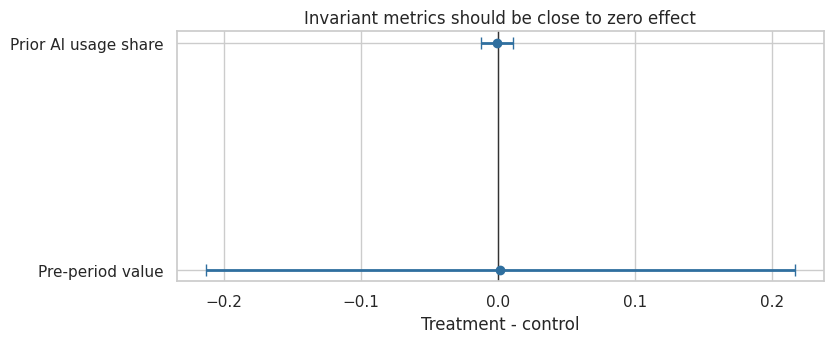

In [8]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(8.5, 3.6))
y = np.arange(len(invariant_table))
ax.errorbar(
    invariant_table["estimate"],
    y,
    xerr=[invariant_table["estimate"] - invariant_table["ci_low"], invariant_table["ci_high"] - invariant_table["estimate"]],
    fmt="o",
    color="#2f6f9f",
    ecolor="#2f6f9f",
    capsize=4,
    elinewidth=2,
)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(invariant_table["metric_label"])
ax.set_title("Invariant metrics should be close to zero effect")
ax.set_xlabel("Treatment - control")
plt.tight_layout()
plt.show()

The invariant effects are close to zero. This supports the basic assignment story. It reduces concern that treatment and control groups are fundamentally different before treatment.

## 5. Primary, Secondary, and Guardrail Metrics

Now we build the metric readout. The table includes:

- Control mean and treatment mean.
- Treatment-control estimate.
- Confidence interval.
- p-value as a continuous evidence summary.
- Practical threshold or guardrail tolerance.
- Decision status.

This is the minimum useful metric table for a launch discussion. It lets the team discuss magnitude and uncertainty rather than relying on arrows.

In [9]:
# Build the summary table used to connect the calculation back to the design question.
metric_plan = pd.DataFrame([
    {
        "metric": "value_14d",
        "metric_label": "14-day account value",
        "role": "primary",
        "type": "continuous",
        "direction": "higher_is_better",
        "practical_threshold": 0.25,
        "unit": "value units",
    },
    {
        "metric": "activation",
        "metric_label": "Activation rate",
        "role": "secondary",
        "type": "binary",
        "direction": "higher_is_better",
        "practical_threshold": 0.00,
        "unit": "share",
    },
    {
        "metric": "retained_14d",
        "metric_label": "14-day retention",
        "role": "secondary",
        "type": "binary",
        "direction": "higher_is_better",
        "practical_threshold": 0.00,
        "unit": "share",
    },
    {
        "metric": "used_assistant",
        "metric_label": "Assistant usage",
        "role": "diagnostic",
        "type": "binary",
        "direction": "higher_is_better",
        "practical_threshold": 0.00,
        "unit": "share",
    },
    {
        "metric": "latency_ms",
        "metric_label": "Latency",
        "role": "guardrail",
        "type": "continuous",
        "direction": "lower_is_better",
        "practical_threshold": 20.0,
        "unit": "milliseconds",
    },
    {
        "metric": "support_tickets",
        "metric_label": "Support tickets",
        "role": "guardrail",
        "type": "continuous",
        "direction": "lower_is_better",
        "practical_threshold": 0.02,
        "unit": "tickets/account",
    },
    {
        "metric": "error_rate",
        "metric_label": "Error rate",
        "role": "guardrail",
        "type": "binary",
        "direction": "lower_is_better",
        "practical_threshold": 0.003,
        "unit": "share",
    },
])

metric_rows = []
for _, spec in metric_plan.iterrows():
    row = summarize_difference(observed_df, spec["metric"], metric_type=spec["type"])
    row.update(spec.to_dict())
    metric_rows.append(row)

metric_table = pd.DataFrame(metric_rows)
metric_table["status"] = metric_table.apply(practical_status, axis=1)
metric_table[[
    "metric_label", "role", "control_mean", "treatment_mean", "estimate", "ci_low", "ci_high", "p_value", "practical_threshold", "status"
]].round(4)

,metric_label,role,control_mean,treatment_mean,estimate,ci_low,ci_high,p_value,practical_threshold,status
0,14-day account value,primary,50.4012,51.0972,0.6961,0.4562,0.9360,0.0000,0.250,decision-grade positive
1,Activation rate,secondary,0.3903,0.4810,0.0907,0.0782,0.1033,0.0000,0.000,diagnostic
2,14-day retention,secondary,0.4599,0.4917,0.0319,0.0192,0.0446,0.0000,0.000,diagnostic
3,Assistant usage,diagnostic,0.2674,0.5421,0.2747,0.2627,0.2867,0.0000,0.000,diagnostic
4,Latency,guardrail,243.2669,255.4077,12.1407,11.2398,13.0417,0.0000,20.000,pass
5,Support tickets,guardrail,0.0822,0.0780,-0.0042,-0.0114,0.0030,0.2572,0.020,pass
6,Error rate,guardrail,0.0106,0.0093,-0.0013,-0.0038,0.0012,0.3049,0.003,pass


In Primary, Secondary, and Guardrail Metrics, the table links the statistical evidence to the launch decision. The table helps separate confirmatory evidence from safety checks and exploratory noise.

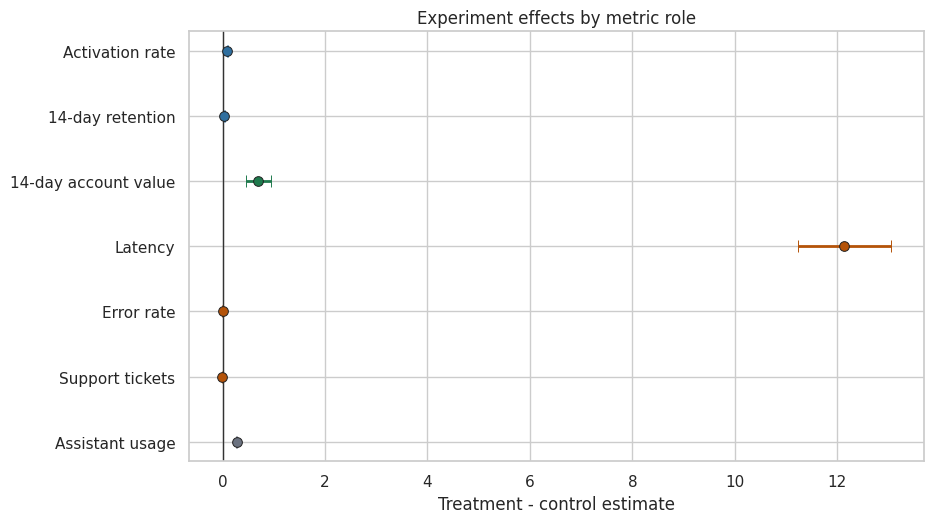

In [10]:
plot_metric_effects(
    metric_table,
    title="Experiment effects by metric role",
    xlabel="Treatment - control estimate",
    figsize=(9.5, 5.4),
)

The primary metric is positive and decision-grade relative to the practical threshold. Activation and assistant usage also move in the expected direction, which supports the mechanism. The guardrails are where the readout gets serious: a launch decision should not be made from the primary metric alone.

Notice that p-values are present, but they are not the decision rule. Wasserstein and Lazar (2016) argue that decisions should not be based only on whether a p-value passes a specific threshold. In business experiments, effect size, confidence interval, practical threshold, opportunity cost, and guardrails all matter.

## 6. Practical Significance and Decision Zones

A confidence interval answers a richer question than "is the p-value below 0.05?"

For the primary metric, the team cares about whether the effect is above a practical threshold:

$$
\text{Ship threshold} = +0.25 \text{ value units}.
$$

The readout should make the threshold visible. A positive estimate below the threshold may be real but not worth launching. An estimate above the threshold with a wide interval may require more data or a staged rollout.

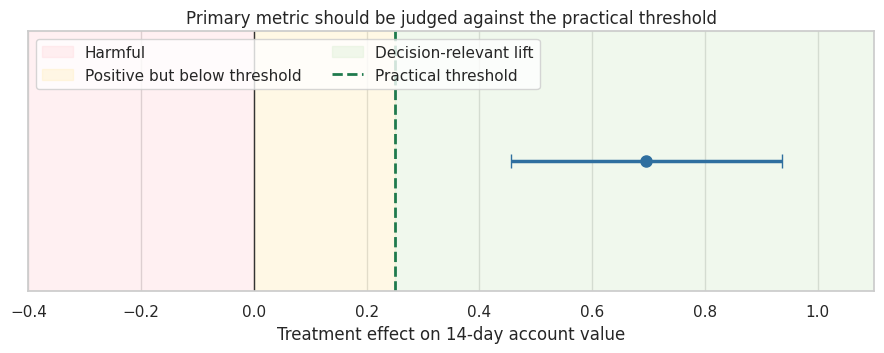

In [11]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
primary = metric_table.query("metric == 'value_14d'").iloc[0]
threshold = primary["practical_threshold"]

fig, ax = plt.subplots(figsize=(9, 3.7))
ax.axvspan(-1.0, 0, color="#ffd6db", alpha=0.35, label="Harmful")
ax.axvspan(0, threshold, color="#fff1c7", alpha=0.45, label="Positive but below threshold")
ax.axvspan(threshold, 1.2, color="#dff0d8", alpha=0.45, label="Decision-relevant lift")
ax.errorbar(
    primary["estimate"],
    0,
    xerr=[[primary["estimate"] - primary["ci_low"]], [primary["ci_high"] - primary["estimate"]]],
    fmt="o",
    color="#2f6f9f",
    ecolor="#2f6f9f",
    capsize=5,
    elinewidth=2.5,
    markersize=8,
)
ax.axvline(0, color="#333333", linewidth=1)
ax.axvline(threshold, color="#1f7a4d", linestyle="--", linewidth=2, label="Practical threshold")
ax.set_yticks([])
ax.set_xlim(-0.4, 1.1)
ax.set_xlabel("Treatment effect on 14-day account value")
ax.set_title("Primary metric should be judged against the practical threshold")
ax.legend(loc="upper left", ncol=2)
plt.tight_layout()
plt.show()

This plot is often more useful than a p-value. The team can see the estimate, the uncertainty interval, zero, and the practical launch threshold in one view.

If the entire interval were below the practical threshold, the readout would recommend against launch even if the p-value were small. If the interval crossed the threshold, the recommendation might be to extend the experiment, narrow eligibility, or run a phased rollout.

## 7. Guardrails as Launch Constraints

Guardrails are not decorative. They are launch constraints.

A feature can improve the primary metric and still fail the experiment if it harms user experience, reliability, fairness, legal risk, platform health, or support burden. Guardrails should have tolerances before the experiment starts.

In [12]:
guardrails = metric_table.query("role == 'guardrail'").copy()
guardrails["guardrail_margin"] = guardrails["practical_threshold"] - guardrails["ci_high"]
guardrails["passes_tolerance"] = guardrails["ci_high"] <= guardrails["practical_threshold"]
guardrails[["metric_label", "estimate", "ci_low", "ci_high", "practical_threshold", "guardrail_margin", "passes_tolerance"]].round(4)

,metric_label,estimate,ci_low,ci_high,practical_threshold,guardrail_margin,passes_tolerance
4,Latency,12.1407,11.2398,13.0417,20.000,6.9583,True
5,Support tickets,-0.0042,-0.0114,0.0030,0.020,0.0170,True
6,Error rate,-0.0013,-0.0038,0.0012,0.003,0.0018,True


In Guardrails as Launch Constraints, the table links the statistical evidence to the launch decision. Primary metrics, guardrails, and multiplicity answer different launch questions.

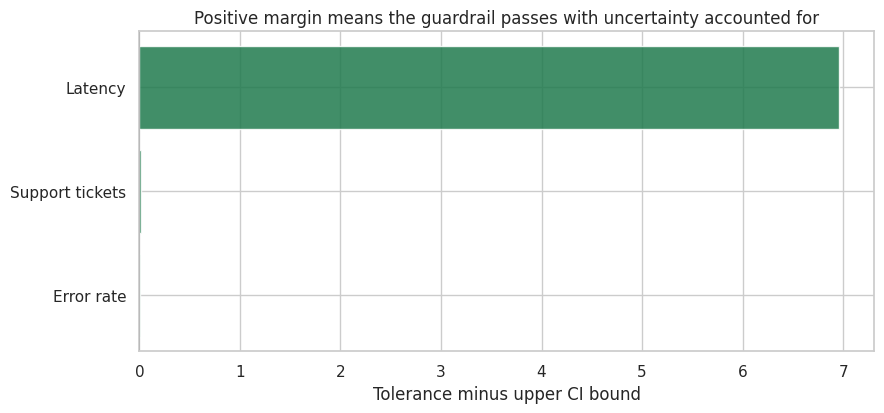

In [13]:
# Build the Guardrails as Launch Constraints plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(9, 4.3))
plot_df = guardrails.sort_values("guardrail_margin")
y = np.arange(len(plot_df))
colors = np.where(plot_df["passes_tolerance"], "#1f7a4d", "#b45309")
ax.barh(y, plot_df["guardrail_margin"], color=colors, alpha=0.85)
ax.axvline(0, color="#333333", linewidth=1.3)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["metric_label"])
ax.set_xlabel("Tolerance minus upper CI bound")
ax.set_title("Positive margin means the guardrail passes with uncertainty accounted for")
plt.tight_layout()
plt.show()

The guardrail margin compares the tolerance with the upper confidence bound of harm. If the upper bound stays below the tolerance, the readout can say the guardrail passed under the pre-specified rule.

This is a conservative habit. It is much better than saying "the guardrail was not statistically significant," because a non-significant guardrail can still allow practically important harm.

## 8. Regression Adjustment as a Sensitivity Check

A readout can include covariate-adjusted estimates, especially when pre-treatment covariates are strongly predictive of outcomes. The key is to use pre-treatment variables only.

Deng, Xu, and Kohavi (2013) discuss using pre-experiment data to improve the sensitivity of online controlled experiments. Athey and Imbens (2017) also emphasize careful analysis of randomized experiments, including covariate adjustment and randomization-based thinking.

Here we compare the unadjusted primary estimate with an adjusted estimate using pre-period value, plan, region, device, and prior AI history.

In [14]:
# Fit the statistical model and collect estimates used in the following interpretation.
unadjusted_primary = summarize_difference(observed_df, "value_14d")
adjusted_model = smf.ols(
    "value_14d ~ assigned + pre_value + C(plan) + C(region) + C(device) + has_ai_history",
    data=observed_df,
).fit(cov_type="HC1")

adjusted_primary = {
    "estimate": adjusted_model.params["assigned"],
    "se": adjusted_model.bse["assigned"],
    "ci_low": adjusted_model.params["assigned"] - 1.96 * adjusted_model.bse["assigned"],
    "ci_high": adjusted_model.params["assigned"] + 1.96 * adjusted_model.bse["assigned"],
    "p_value": adjusted_model.pvalues["assigned"],
}

sensitivity_table = pd.DataFrame([
    {"method": "Unadjusted difference in means", **unadjusted_primary},
    {"method": "Adjusted regression", **adjusted_primary},
])
sensitivity_table[["method", "estimate", "se", "ci_low", "ci_high", "p_value"]].round(4)

,method,estimate,se,ci_low,ci_high,p_value
0,Unadjusted difference in means,0.6961,0.1224,0.4562,0.9360,0.0
1,Adjusted regression,0.6555,0.0971,0.4652,0.8458,0.0


In Regression Adjustment as a Sensitivity Check, the adjusted model should reinforce the randomized readout rather than become a separate fishing exercise. The launch decision still rests on the pre-specified metric structure.

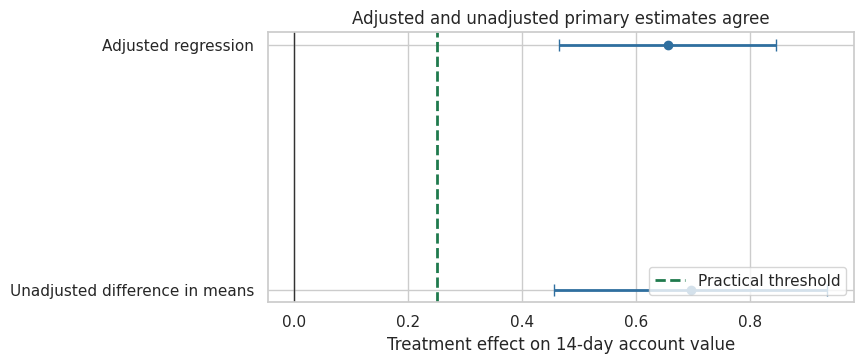

In [15]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(8.8, 3.8))
y = np.arange(len(sensitivity_table))
ax.errorbar(
    sensitivity_table["estimate"],
    y,
    xerr=[sensitivity_table["estimate"] - sensitivity_table["ci_low"], sensitivity_table["ci_high"] - sensitivity_table["estimate"]],
    fmt="o",
    color="#2f6f9f",
    ecolor="#2f6f9f",
    capsize=4,
    elinewidth=2,
)
ax.axvline(0, color="#333333", linewidth=1)
ax.axvline(threshold, color="#1f7a4d", linestyle="--", linewidth=2, label="Practical threshold")
ax.set_yticks(y)
ax.set_yticklabels(sensitivity_table["method"])
ax.set_xlabel("Treatment effect on 14-day account value")
ax.set_title("Adjusted and unadjusted primary estimates agree")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

The adjusted estimate is similar to the unadjusted estimate, with somewhat improved precision. This strengthens the readout because the primary conclusion is not fragile to a reasonable pre-specified adjustment.

The analysis should not adjust for post-treatment variables such as activation or assistant usage when estimating the total effect of assignment. Those variables are mechanisms, not baseline controls.

## 9. Segment Analysis: Useful, but Dangerous

Segments are valuable for diagnosis and product learning. They are also a classic source of overclaiming.

A segment readout should distinguish:

- Pre-specified decision segments.
- Exploratory diagnostic segments.
- Segments with enough sample size to say anything useful.
- Segments where confidence intervals are too wide for decisions.

The more segments we inspect, the easier it is to find a noisy winner or loser. Segment analysis should usually inform follow-up experiments, targeted rollouts, or product investigation rather than replace the primary decision rule.

In [16]:
# Assemble the Segment Analysis: Useful, but Dangerous summary table used for interpretation.
segment_rows = []
for segment_col in ["plan", "region", "device", "has_ai_history"]:
    for level, part in observed_df.groupby(segment_col):
        if part["assigned"].nunique() < 2 or len(part) < 300:
            continue
        row = summarize_difference(part, "value_14d")
        row.update({"segment": segment_col, "level": str(level), "n": len(part)})
        segment_rows.append(row)
segment_table = pd.DataFrame(segment_rows)
segment_table["label"] = segment_table["segment"] + " = " + segment_table["level"]
segment_table[["label", "n", "estimate", "ci_low", "ci_high", "p_value"]].round(3)

,label,n,estimate,ci_low,ci_high,p_value
0,plan = enterprise,5661,1.188,0.724,1.651,0.000
1,plan = growth,9975,0.666,0.322,1.011,0.000
2,plan = startup,8108,0.174,-0.206,0.553,0.370
3,region = APAC,4408,0.920,0.365,1.476,0.001
4,region = Europe,7268,0.455,0.027,0.884,0.037
5,region = LATAM,1675,0.535,-0.367,1.436,0.245
6,region = North America,10393,0.819,0.455,1.182,0.000
7,device = desktop,17148,0.653,0.371,0.934,0.000
8,device = mobile,6596,0.809,0.352,1.267,0.001
9,has_ai_history = 0,16589,0.669,0.386,0.952,0.000


In Segment Analysis: Useful, but Dangerous, the table links the statistical evidence to the launch decision. The primary metric says what improved; guardrails and multiplicity checks keep that evidence honest.

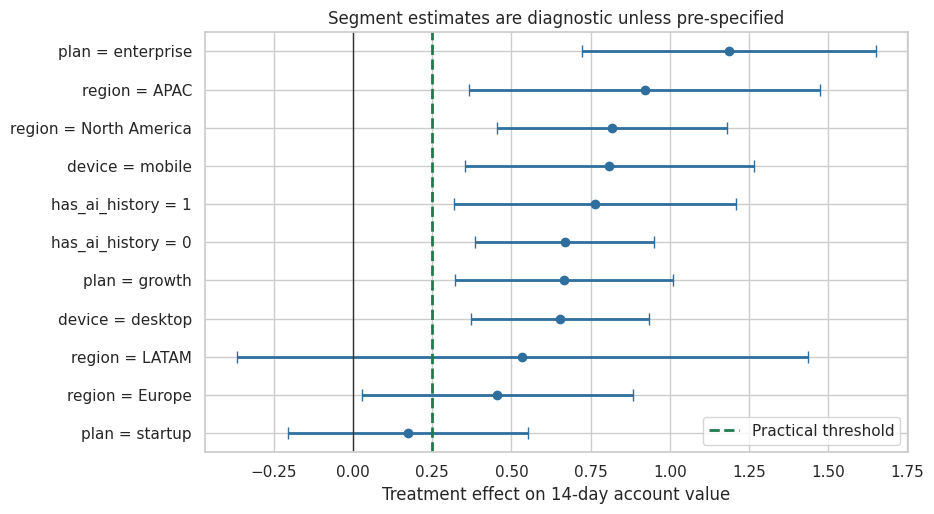

In [17]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
ordered_segments = segment_table.sort_values("estimate")
fig, ax = plt.subplots(figsize=(9.5, 5.3))
y = np.arange(len(ordered_segments))
ax.errorbar(
    ordered_segments["estimate"],
    y,
    xerr=[ordered_segments["estimate"] - ordered_segments["ci_low"], ordered_segments["ci_high"] - ordered_segments["estimate"]],
    fmt="o",
    color="#2f6f9f",
    ecolor="#2f6f9f",
    capsize=4,
    elinewidth=2,
)
ax.axvline(0, color="#333333", linewidth=1)
ax.axvline(threshold, color="#1f7a4d", linestyle="--", linewidth=2, label="Practical threshold")
ax.set_yticks(y)
ax.set_yticklabels(ordered_segments["label"])
ax.set_xlabel("Treatment effect on 14-day account value")
ax.set_title("Segment estimates are diagnostic unless pre-specified")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

The segment plot suggests where the effect may be stronger or weaker. But this should be read as diagnostic evidence unless those segment hypotheses were pre-specified and powered.

A good business readout might say: "The primary effect supports launch. Segment diagnostics suggest enterprise accounts may benefit more; we recommend monitoring this in rollout and considering a follow-up test for tailored onboarding."

## 10. Mechanism and Funnel Diagnostics

Mechanism metrics explain why the primary metric moved. They usually inform learning and diagnosis rather than the launch rule.

For this experiment, the mechanism is:

1. Assignment exposes accounts to the AI onboarding assistant.
2. More accounts use the assistant.
3. More accounts activate.
4. Activated accounts generate more 14-day value.

A readout should present mechanism metrics as supporting evidence, not as a substitute for the primary metric.

In [18]:
# Assemble the Mechanism and Funnel Diagnostics summary table used for interpretation.
funnel_metrics = ["used_assistant", "activation", "retained_14d"]
funnel_labels = {
    "used_assistant": "Used assistant",
    "activation": "Activated",
    "retained_14d": "Retained 14 days",
}
funnel_rows = []
for metric in funnel_metrics:
    grouped = observed_df.groupby("assigned")[metric].mean()
    funnel_rows.append({
        "step": funnel_labels[metric],
        "control": grouped.loc[0],
        "treatment": grouped.loc[1],
        "lift": grouped.loc[1] - grouped.loc[0],
    })
funnel_table = pd.DataFrame(funnel_rows)
funnel_table.round(4)

,step,control,treatment,lift
0,Used assistant,0.2674,0.5421,0.2747
1,Activated,0.3903,0.4810,0.0907
2,Retained 14 days,0.4599,0.4917,0.0319


In Mechanism and Funnel Diagnostics, read the table together with assignment quality, metric definitions, uncertainty, and guardrails. The randomized estimate is the evidence base, and the launch decision also needs magnitude and guardrails.

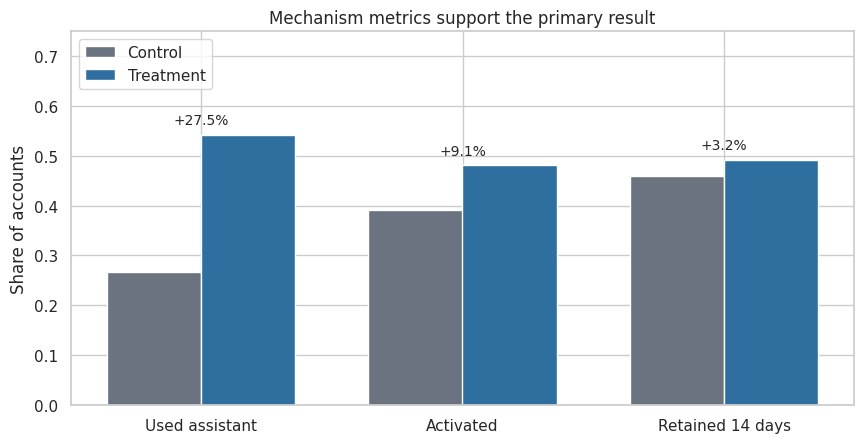

In [19]:
# Build the Mechanism and Funnel Diagnostics plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(8.8, 4.6))
x = np.arange(len(funnel_table))
width = 0.36
ax.bar(x - width/2, funnel_table["control"], width=width, label="Control", color="#6b7280")
ax.bar(x + width/2, funnel_table["treatment"], width=width, label="Treatment", color="#2f6f9f")
for i, lift in enumerate(funnel_table["lift"]):
    ax.text(i, max(funnel_table.loc[i, ["control", "treatment"]]) + 0.015, f"+{lift:.1%}", ha="center", va="bottom", fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(funnel_table["step"])
ax.set_ylim(0, 0.75)
ax.set_ylabel("Share of accounts")
ax.set_title("Mechanism metrics support the primary result")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

The treatment increases assistant usage and activation. Retention moves only modestly. That is a coherent story for a short-term onboarding assistant: the immediate mechanism is activation and early value, while retention may need longer follow-up.

A good readout separates this mechanism story from the launch rule. The mechanism story helps product teams improve the feature; the launch rule should still depend on the primary metric and guardrails.

## 11. Decision Matrix

A launch recommendation should combine the evidence into a small number of possible actions.

| Primary metric | Guardrails | Typical recommendation |
|---|---|---|
| Clears practical threshold | Pass | Launch or staged rollout |
| Clears threshold | One guardrail uncertain | Staged rollout with monitoring or fix guardrail first |
| Positive but below threshold | Pass | Iterate; do not full launch yet |
| Uncertain | Pass | Extend experiment or narrow to promising segment |
| Negative | Any | Do not launch |
| Positive | Guardrail fails | Do not launch until harm is addressed |

This matrix is intentionally simple. Real decisions include engineering cost, opportunity cost, strategic value, risk tolerance, and customer commitments. But the readout should make the statistical evidence legible before that business judgment is applied.

In [20]:
# Build the summary table used to connect the calculation back to the design question.
primary_pass = primary["ci_low"] >= primary["practical_threshold"]
guardrails_pass = bool(guardrails["passes_tolerance"].all())
telemetry_watch = telemetry_table["telemetry_rate"].min() < 0.98

if primary_pass and guardrails_pass and not telemetry_watch:
    recommendation = "Launch"
elif primary_pass and guardrails_pass and telemetry_watch:
    recommendation = "Staged rollout with telemetry monitoring"
elif primary_pass and not guardrails_pass:
    recommendation = "Do not launch until guardrail risk is addressed"
elif primary["estimate"] > 0:
    recommendation = "Iterate or extend experiment"
else:
    recommendation = "Do not launch"

recommendation_card = pd.DataFrame({
    "criterion": [
        "Primary metric clears threshold",
        "All guardrails pass",
        "Telemetry completeness healthy",
        "Recommended action",
    ],
    "readout": [
        str(primary_pass),
        str(guardrails_pass),
        str(not telemetry_watch),
        recommendation,
    ],
})
smart_display(recommendation_card)

,criterion,readout
0,Primary metric clears threshold,True
1,All guardrails pass,True
2,Telemetry completeness healthy,True
3,Recommended action,Launch


In Decision Matrix, the table links the statistical evidence to the launch decision. A launch readout needs the primary result, the guardrail risks, and the multiplicity story in the same frame.

In [21]:
# Organize the calculation into readable steps for the lecture narrative.
summary_numbers = {
    "primary_estimate": primary["estimate"],
    "primary_ci": (primary["ci_low"], primary["ci_high"]),
    "activation_lift": metric_table.query("metric == 'activation'").iloc[0]["estimate"],
    "usage_lift": metric_table.query("metric == 'used_assistant'").iloc[0]["estimate"],
    "latency_effect": metric_table.query("metric == 'latency_ms'").iloc[0]["estimate"],
    "min_telemetry": telemetry_table["telemetry_rate"].min(),
}

executive_summary = f"""
### Draft Executive Summary

**Recommendation:** {recommendation}.

The AI onboarding assistant increased the primary metric, 14-day account value, by **{summary_numbers['primary_estimate']:.2f} value units** with a 95% interval of **[{summary_numbers['primary_ci'][0]:.2f}, {summary_numbers['primary_ci'][1]:.2f}]**. The interval clears the pre-specified practical threshold of **+{threshold:.2f}** value units.

Mechanism metrics are directionally coherent: assistant usage increased by **{summary_numbers['usage_lift']:.1%}** and activation increased by **{summary_numbers['activation_lift']:.1%}**. Guardrails passed the pre-specified tolerances. Latency increased by **{summary_numbers['latency_effect']:.1f} ms**, below the +20 ms tolerance.

Trust checks were acceptable, with balanced assignment and no material pre-period imbalance. Telemetry completeness was at least **{summary_numbers['min_telemetry']:.1%}** across variant-device cells, so rollout should include continued telemetry monitoring.
"""

smart_display(Markdown(executive_summary))


### Draft Executive Summary

**Recommendation:** Launch.

The AI onboarding assistant increased the primary metric, 14-day account value, by **0.70 value units** with a 95% interval of **[0.46, 0.94]**. The interval clears the pre-specified practical threshold of **+0.25** value units.

Mechanism metrics are directionally coherent: assistant usage increased by **27.5%** and activation increased by **9.1%**. Guardrails passed the pre-specified tolerances. Latency increased by **12.1 ms**, below the +20 ms tolerance.

Trust checks were acceptable, with balanced assignment and no material pre-period imbalance. Telemetry completeness was at least **98.1%** across variant-device cells, so rollout should include continued telemetry monitoring.


This executive summary does four things well:

1. It starts with the recommendation.
2. It gives the primary effect with uncertainty and the practical threshold.
3. It states guardrail and trust-check status.
4. It includes the caveat that should carry into rollout monitoring.

The aim is to put statistical detail in the right order for decision-making.

## 12. Common Readout Failure Modes

| Failure mode | Why it is dangerous | Better practice |
|---|---|---|
| Leading with p-values | Hides magnitude and practical importance | Lead with decision, effect size, CI, threshold |
| Metric dump | Makes every metric look equally decision-relevant | Separate primary, secondary, guardrail, diagnostic metrics |
| Ignoring trust checks | Can interpret broken data as causal evidence | Start with SRM, logging, invariants, eligibility |
| Treating guardrails as optional | Allows harmful launches | Pre-specify tolerances and launch constraints |
| Overclaiming segments | Turns noisy exploration into policy | Label segment work as exploratory unless powered and pre-specified |
| Adjusting for post-treatment variables | Blocks part of the causal effect | Use only pre-treatment covariates for adjustment |
| Confusing assignment and usage | Changes estimand silently | Report ITT, first stage, and TOT/LATE separately when needed |
| Ignoring interference | Misstates rollout effects | Use cluster, geo, network, or saturation designs when needed |
| Saying "no effect" from a wide CI | Confuses absence of evidence with evidence of absence | Discuss uncertainty and detectable effect sizes |
| Omitting recommendation | Leaves stakeholders to reverse-engineer the decision | End with a clear action and monitoring plan |

A senior causal inference practitioner is not just someone who can estimate an effect. They are someone who can protect the organization from making the wrong decision from a noisy or misread effect.

## 13. A Reusable Readout Template

Use this outline for future experiments.

| Section | Content |
|---|---|
| Decision | What decision does this experiment inform? |
| Design | Randomization unit, eligibility, variants, dates, planned sample |
| Metric hierarchy | Primary, secondary, guardrail, diagnostic, invariant metrics |
| Trust checks | SRM, logging, telemetry, missingness, invariants, data quality |
| Primary result | Estimate, CI, p-value, practical threshold, interpretation |
| Guardrails | Estimate, CI, tolerance, pass/fail status |
| Sensitivity | Adjusted estimates, alternative windows, triggered/all-eligible views |
| Diagnostics | Funnels, segments, mechanism metrics, heterogeneity exploration |
| Caveats | Noncompliance, interference, external validity, novelty effects, measurement issues |
| Recommendation | Launch, staged rollout, iterate, extend, or do not launch |
| Monitoring | Metrics and thresholds to track after rollout |

Kohavi et al. (2020) emphasize trustworthiness in online controlled experiments; in practice, trustworthiness is an end-to-end property of design, instrumentation, analysis, interpretation, and decision process.

In [22]:
# Build the summary table used to connect the calculation back to the design question.
readout_template = pd.DataFrame({
    "readout_field": [
        "Decision",
        "Primary metric",
        "Practical threshold",
        "Trust checks",
        "Primary result",
        "Guardrail result",
        "Sensitivity result",
        "Diagnostics",
        "Recommendation",
        "Rollout monitoring",
    ],
    "example_entry": [
        "Roll out AI onboarding assistant to all eligible enterprise accounts?",
        "14-day account value",
        "+0.25 value units",
        "Assignment balanced; invariants balanced; telemetry watch on mobile treatment",
        f"+{primary['estimate']:.2f} value units, 95% CI [{primary['ci_low']:.2f}, {primary['ci_high']:.2f}]",
        "Latency, tickets, and errors pass tolerances",
        f"Adjusted estimate +{adjusted_primary['estimate']:.2f}, similar to unadjusted",
        "Usage and activation increased; enterprise segment appears strongest",
        recommendation,
        "Monitor latency, support tickets, telemetry completeness, and 30-day retention",
    ],
})
smart_display(readout_template)

,readout_field,example_entry
0,Decision,Roll out AI onboarding assistant to all eligib...
1,Primary metric,14-day account value
2,Practical threshold,+0.25 value units
3,Trust checks,Assignment balanced; invariants balanced; tele...
4,Primary result,"+0.70 value units, 95% CI [0.46, 0.94]"
5,Guardrail result,"Latency, tickets, and errors pass tolerances"
6,Sensitivity result,"Adjusted estimate +0.66, similar to unadjusted"
7,Diagnostics,Usage and activation increased; enterprise seg...
8,Recommendation,Launch
9,Rollout monitoring,"Monitor latency, support tickets, telemetry co..."


## 14. Key Takeaways

- A readout should be organized around a decision, not around a table of all available metrics.
- Trust checks come first: assignment integrity, telemetry, invariants, eligibility, and missingness.
- The primary metric should be interpreted with effect size, uncertainty, and a practical threshold.
- Guardrails are launch constraints, not optional supporting metrics.
- A p-value is not a measure of effect size or business importance; it should not be the sole decision rule.
- Regression adjustment can improve precision when it uses pre-treatment covariates and is planned responsibly.
- Segment and funnel diagnostics are useful for learning but dangerous when overclaimed.
- A strong executive summary states the recommendation, primary effect, uncertainty, guardrail status, trust-check status, caveats, and monitoring plan.
- The best causal inference work does not end with estimation. It ends with a better decision.

This completes the experiments section. The next part of the lecture sequence will move from randomized experiments into observational causal inference, where identification assumptions become even more central.

## References

Athey, S., & Imbens, G. W. (2017). The econometrics of randomized experiments. *Handbook of Economic Field Experiments*, 73-140. https://doi.org/10.1016/bs.hefe.2016.10.003

Bojinov, I., & Gupta, S. (2022). Online experimentation: Benefits, operational and methodological challenges, and scaling guide. *MIT Press*. https://doi.org/10.1162/99608f92.a579756e

Deng, A., Xu, Y., & Kohavi, R. (2013). Improving the sensitivity of online controlled experiments by utilizing pre-experiment data. *Proceedings of the Sixth ACM International Conference on Web Search and Data Mining*, 123-132. https://doi.org/10.1145/2433396.2433413

Gupchup, J., Hosseinkashi, Y., Dmitriev, P., & Dykstra, J. (2018). Trustworthy experimentation under telemetry loss. *Proceedings of the 27th ACM International Conference on Information and Knowledge Management*, 387-396. https://doi.org/10.1145/3269206.3271747

Kohavi, R., Crook, T. R., Frasca, B., Henne, R. M., Longbotham, R., & Walker, T. (2009). Seven pitfalls to avoid when running controlled experiments on the web. *Proceedings of the 15th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1105-1114. https://doi.org/10.1145/1557019.1557139

Kohavi, R., Tang, D., & Xu, Y. (2020). *Trustworthy online controlled experiments: A practical guide to A/B testing*. Cambridge University Press. https://doi.org/10.1017/9781108653985

Wasserstein, R. L., & Lazar, N. A. (2016). The ASA statement on p-values: Context, process, and purpose. *The American Statistician, 70*(2), 129-133. https://doi.org/10.1080/00031305.2016.1154108